#### This sript is a standalone test script (not part of the final application)
#### for training an XGBoost model using preprocessed data
Goal is to test the change in prediction accuracy by using 
## 1. different hyperparameters 
## 2. additional input parameters and 
## 3. additional training data

In [17]:
# FROST fetch: server-side filtering + compact payload + parallel requests
import requests
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

# --- Config: your datastreams + date window (UTC) ---
datastreams = [
    ("BG.West.010", "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(1)/Observations?$orderby=phenomenonTime desc"),
    ("BG.West.270", "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(7)/Observations?$orderby=phenomenonTime desc"),
    ("01.West.120", "https://multicare.bk.tudelft.nl/FROST-Server/v1.0/Datastreams(13)/Observations?$orderby=phenomenonTime desc"),
]
start_date = pd.Timestamp("2025-01-01", tz="UTC")
end_date   = pd.Timestamp("2025-05-31 23:59:59", tz="UTC")

# --- Tuning knobs ---
PAGE_SIZE   = 1000   # try larger if the server allows (e.g., 2000)
TIMEOUT     = 30     # per-request timeout (seconds)
MAX_WORKERS = 3      # one per datastream

# --- Helper: phenomenonTime can be 'start/end' or a single instant ---
def parse_phenomenon_time(value: str) -> pd.Timestamp:
    # Most FROST servers return instants; keep split for safety if an interval appears
    if isinstance(value, str) and "/" in value:
        value = value.split("/")[0]
    return pd.to_datetime(value, errors="coerce", utc=True)

# --- Build a filtered, compact URL (drops $orderby, adds $filter/$select/$top) ---
def build_filtered_url(base_url: str, start: pd.Timestamp, end: pd.Timestamp, top: int) -> str:
    # Remove any $orderby to avoid expensive server-side sorting
    if "$orderby=" in base_url:
        parts = [p for p in base_url.split("&") if not p.startswith("$orderby=")]
        base_url = "&".join(parts)

    sep = "&" if "?" in base_url else "?"
    start_iso = start.strftime("%Y-%m-%dT%H:%M:%SZ")
    end_iso   = end.strftime("%Y-%m-%dT%H:%M:%SZ")

    additions = [
        f"$filter=phenomenonTime ge {start_iso} and phenomenonTime le {end_iso}",
        "$select=phenomenonTime,result",
        f"$top={top}",
        # If your server supports it, uncomment the next line for even faster/leaner responses:
        # "$resultFormat=dataArray"
    ]
    return base_url + sep + "&".join(additions)

# --- Core fetch: follow @iot.nextLink only (no extra request per page) ---
def fetch_all_filtered(base_url: str, start: pd.Timestamp, end: pd.Timestamp, page_size: int = 1000, session: requests.Session | None = None) -> pd.DataFrame:
    sess = session or requests.Session()
    headers = {"Accept": "application/json;odata.metadata=none", "Accept-Encoding": "gzip, deflate"}

    url = build_filtered_url(base_url, start, end, page_size)
    rows = []

    while url:
        r = sess.get(url, headers=headers, timeout=TIMEOUT)
        r.raise_for_status()
        payload = r.json()

        vals = payload.get("value", [])
        if not vals:
            break

        rows.extend(
            {"timestamp": parse_phenomenon_time(o.get("phenomenonTime")), "internal_temp": o.get("result")}
            for o in vals
        )

        url = payload.get("@iot.nextLink")  # follow server paging

    if not rows:
        return pd.DataFrame(columns=["timestamp", "internal_temp"])

    df = pd.DataFrame(rows)
    # Ensure types + clean
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
    df["internal_temp"] = pd.to_numeric(df["internal_temp"], errors="coerce")
    df = (
        df.dropna(subset=["timestamp"])
          .drop_duplicates(subset=["timestamp", "internal_temp"])  # dedupe by both fields
          .sort_values("timestamp")
          .reset_index(drop=True)
    )
    return df

# --- Wrapper to fetch one stream (with safety) ---
def fetch_one(name_url):
    name, url = name_url
    print(f"Fetching {name} ...")
    try:
        with requests.Session() as sess:
            df = fetch_all_filtered(url, start_date, end_date, page_size=PAGE_SIZE, session=sess)
        print(f"  {name}: {len(df)} rows")
        return name, df
    except Exception as e:
        print(f"  {name}: ERROR -> {e}")
        return name, pd.DataFrame(columns=["timestamp", "internal_temp"])

# --- Parallel fetching for all streams ---
sensor_data: dict[str, pd.DataFrame] = {}
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
    futures = {ex.submit(fetch_one, pair): pair[0] for pair in datastreams}
    for fut in as_completed(futures):
        name, df = fut.result()
        sensor_data[name] = df

# --- Combine for analysis/plotting (adds sensor label) ---
combined = (
    pd.concat([df.assign(sensor=name) for name, df in sensor_data.items()], ignore_index=True)
    if sensor_data else
    pd.DataFrame(columns=["timestamp", "internal_temp", "sensor"])
)

print("\nCombined head():")
print(combined.head())
print("\nCounts by sensor:")
print(combined.groupby("sensor")["internal_temp"].count())

# --- Hourly average ---
hourly_avg = (
    combined
    .set_index("timestamp")              # make timestamp the index
    .groupby("sensor")                   # keep averages separate per sensor
    .resample("1h")                       # hourly bins
    .mean(numeric_only=True)              # mean of numeric columns
    .reset_index()
)

print("\nHourly average head():")
print(hourly_avg.head())

Fetching BG.West.010 ...
Fetching BG.West.270 ...
Fetching 01.West.120 ...
  01.West.120: 7731 rows
  BG.West.270: 8362 rows
  BG.West.010: 8362 rows

Combined head():
                  timestamp  internal_temp       sensor
0 2025-03-23 12:19:49+00:00           23.4  01.West.120
1 2025-03-23 12:29:52+00:00           23.3  01.West.120
2 2025-03-23 12:39:56+00:00           23.2  01.West.120
3 2025-03-23 12:50:01+00:00           23.2  01.West.120
4 2025-03-23 13:00:05+00:00           23.0  01.West.120

Counts by sensor:
sensor
01.West.120    7731
BG.West.010    8362
BG.West.270    8362
Name: internal_temp, dtype: int64

Hourly average head():
        sensor                 timestamp  internal_temp
0  01.West.120 2025-03-23 12:00:00+00:00      23.275000
1  01.West.120 2025-03-23 13:00:00+00:00      22.950000
2  01.West.120 2025-03-23 14:00:00+00:00      22.800000
3  01.West.120 2025-03-23 15:00:00+00:00      22.633333
4  01.West.120 2025-03-23 16:00:00+00:00      22.516667


Now that data from sensors is in a readable dataframe, I want to combine this with the external sensor data from NetCDF file (downloaded from Davis weather station data at Green Village)

In [18]:
# === External weather from NetCDF (Jan–May 2025) ===
import pandas as pd
import xarray as xr
from pathlib import Path
#  path for the NetCDF file downloaded from Davis weather station data at Green Village
nc_files = [
    "../input/ExternalTemp/davis-TUD-GV_Green_Village_202501.nc",
    "../input/ExternalTemp/davis-TUD-GV_Green_Village_202502.nc",
    "../input/ExternalTemp/davis-TUD-GV_Green_Village_202503.nc",
    "../input/ExternalTemp/davis-TUD-GV_Green_Village_202504.nc",
    "../input/ExternalTemp/davis-TUD-GV_Green_Village_202505.nc",
]

# 2) Helper to read one NetCDF into a tidy DataFrame
def _read_nc_to_df(path: str | Path) -> pd.DataFrame:
    ds = xr.open_dataset(path)
    df = ds.to_dataframe().reset_index()

    # Keep only relevant columns if present
    keep_time_cols = [c for c in ["epoch_time", "time", "time_as_string"] if c in df.columns]
    keep_sensor_cols = [c for c in ["pressure", "temperature", "humidity", "solar_irradiance", "wind_speed"] if c in df.columns]

    return df[keep_time_cols + keep_sensor_cols]
# 3) Read and combine all months
ext_raw_list = []
for f in nc_files:
    try:
        ext_raw_list.append(_read_nc_to_df(f))
    except Exception as e:
        print(f"[WARN] Failed reading {f}: {e}")

if ext_raw_list:
    ext_raw = pd.concat(ext_raw_list, ignore_index=True)
else:
    ext_raw = pd.DataFrame(columns=["epoch_time", "pressure", "temperature", "humidity", "solar_irradiance", "wind_speed"])

# 4) Coerce selected sensor columns to numeric
sensor_cols = [c for c in ["pressure", "temperature", "humidity", "solar_irradiance", "wind_speed"] if c in ext_raw.columns]
for c in sensor_cols:
    ext_raw[c] = pd.to_numeric(ext_raw[c], errors="coerce")

# 5) Convert epoch_time → UTC timestamp (to match FROST timestamps)
ext_raw["timestamp_utc"] = pd.to_datetime(pd.to_numeric(ext_raw["epoch_time"], errors="coerce"), unit="s", utc=True)

# 6) Basic cleanup: drop bad timestamps, sort, and drop exact duplicates
ext_clean = (
    ext_raw.dropna(subset=["timestamp_utc"])
           .drop_duplicates(subset=["timestamp_utc"] + sensor_cols)  # dedupe on time+values
           .sort_values("timestamp_utc")
           .reset_index(drop=True)
)

# 7) Index by time and resample to hourly means
ext_hourly = (
    ext_clean.set_index("timestamp_utc")[sensor_cols]  # index on UTC time; keeping only sensor cols
             .resample("1h")
             .mean()                                   # NaNs ignored; all-NaN hour remains NaN
             .reset_index()
)

# ---- local time (e.g., Europe/Amsterdam) ----
ext_hourly["time_local"] = ext_hourly["timestamp_utc"].dt.tz_convert("Europe/Amsterdam")

#checks
print("External hourly head():")
print(ext_hourly.head())
print(f"Total rows in ext_hourly: {len(ext_hourly)}")
print("Counts per column (non-NaN):")
print(ext_hourly[sensor_cols].count())


External hourly head():
              timestamp_utc     pressure  temperature  humidity  \
0 2025-01-01 00:00:00+00:00  1015.264587          NaN       NaN   
1 2025-01-01 01:00:00+00:00  1014.984619          NaN       NaN   
2 2025-01-01 02:00:00+00:00  1014.504272          NaN       NaN   
3 2025-01-01 03:00:00+00:00  1014.489624          NaN       NaN   
4 2025-01-01 04:00:00+00:00  1014.516235          NaN       NaN   

   solar_irradiance  wind_speed                time_local  
0               NaN         NaN 2025-01-01 01:00:00+01:00  
1               NaN         NaN 2025-01-01 02:00:00+01:00  
2               NaN         NaN 2025-01-01 03:00:00+01:00  
3               NaN         NaN 2025-01-01 04:00:00+01:00  
4               NaN         NaN 2025-01-01 05:00:00+01:00  
Total rows in ext_hourly: 3625
Counts per column (non-NaN):
pressure            3566
temperature         3289
humidity            3331
solar_irradiance    3331
wind_speed          3328
dtype: int64


### Combining the two dataframes
1. hourly_avg (from FROST, per-sensor hourly means; cols: timestamp, internal_temp, sensor)
2. ext_hourly (from NetCDF, hourly means; cols: timestamp_utc, pressure, temperature, humidity, solar_irradiance, wind_speed)

since both these dataframes have agerage hourly values, they are combined with a tolerance of 30 min, keeping all FROST rows (left-asof join) and pulling the closest external record per row.

In [19]:
# Join FROST hourly (internal_temp) with NetCDF hourly (external variables) on nearest time 
import pandas as pd

# Prepare FROST hourly
frost_hourly = hourly_avg.rename(columns={"timestamp": "timestamp_utc"}).copy()
# (keeps columns: timestamp_utc, internal_temp, sensor)

# Prepare NetCDF hourly
ext_prep = ext_hourly.rename(columns={"temperature": "external_temp"}).copy()
# (columns include: timestamp_utc, external_temp, pressure, humidity, solar_irradiance, wind_speed)

# Sort (required by merge_asof)
frost_sorted = frost_hourly.sort_values("timestamp_utc").reset_index(drop=True)
ext_sorted   = ext_prep.sort_values("timestamp_utc").reset_index(drop=True)

# Nearest-time join with 30-min tolerance
combined_nearest = pd.merge_asof(
    frost_sorted,
    ext_sorted,
    on="timestamp_utc",
    direction="nearest",
    tolerance=pd.Timedelta("30min")
)

# Optional diagnostics
matched = combined_nearest["external_temp"].notna().sum()
total   = len(combined_nearest)
print(f"Nearest-join matched rows: {matched}/{total} (tolerance=30 min)")

print("\nCombined (nearest) head():")
print(combined_nearest.head())



Nearest-join matched rows: 4899/5004 (tolerance=30 min)

Combined (nearest) head():
        sensor             timestamp_utc  internal_temp     pressure  \
0  01.West.120 2025-03-23 12:00:00+00:00      23.275000  1003.960815   
1  BG.West.270 2025-03-23 12:00:00+00:00      24.000000  1003.960815   
2  BG.West.010 2025-03-23 12:00:00+00:00      23.000000  1003.960815   
3  01.West.120 2025-03-23 13:00:00+00:00      22.950000  1004.053406   
4  BG.West.270 2025-03-23 13:00:00+00:00      24.016667  1004.053406   

   external_temp   humidity  solar_irradiance  wind_speed  \
0      17.624500  52.383333        566.666667    0.230971   
1      17.624500  52.383333        566.666667    0.230971   
2      17.624500  52.383333        566.666667    0.230971   
3      17.818666  50.083333        307.766667    0.089408   
4      17.818666  50.083333        307.766667    0.089408   

                 time_local  
0 2025-03-23 13:00:00+01:00  
1 2025-03-23 13:00:00+01:00  
2 2025-03-23 13:00:00+01:0

### Basic Cleanup 

In [20]:
# some basic cleanup on combined_nearest
# 1. drop rows where internal_temp is missing (no imputation for target)
# 2. remove outliers (> 4σ) in any numeric column (per sensor)
# 3. fill remaining gaps in predictors by averaging the preceding & succeeding timestamps only (i.e., time interpolation inside gaps); if either side is missing, the row is dropped

import numpy as np
import pandas as pd
df = combined_nearest.copy()

# 1) Keep only rows with internal temperature present (target must exist)
before = len(df)
df = df.dropna(subset=["internal_temp"])
print(f"Dropped rows with missing internal_temp: {before - len(df)}")

# Identify feature columns present
feature_cols = [c for c in ["external_temp", "pressure", "humidity", "solar_irradiance", "wind_speed"] if c in df.columns]
numeric_cols = ["internal_temp"] + feature_cols

# 2) Outlier removal: per-sensor, drop rows where ANY numeric col is > 4 std from its mean
#    (NaNs are ignored for mean/std; rows where std is 0 will not be flagged)
def _zscore_per_sensor(s):
    grp = df.groupby("sensor")[s]
    mean = grp.transform("mean")
    std  = grp.transform("std")
    z = (df[s] - mean) / std
    return z

mask_ok = np.ones(len(df), dtype=bool)
for col in numeric_cols:
    z = _zscore_per_sensor(col)
    # keep rows where |z| <= 4 OR z is NaN (can't judge), but drop where |z| > 4
    # Note: if std==0, z becomes NaN; those rows are kept.
    mask_ok &= z.abs().le(4) | z.isna()

outlier_dropped = (~mask_ok).sum()
df = df[mask_ok].copy()
print(f"Dropped outliers (>4σ) across numeric columns: {outlier_dropped}")

# 3) Interpolate ONLY inside gaps for feature columns (not internal_temp),
#    per sensor, using time-based interpolation. Rows still NaN afterward (edges)
#    will be dropped.

def _interp_group(g: pd.DataFrame) -> pd.DataFrame:
    g = g.sort_values("timestamp_utc").set_index("timestamp_utc")
    # interpolate only inside gaps (requires both a previous and next value)
    g[feature_cols] = g[feature_cols].interpolate(method="time", limit_area="inside")
    return g.reset_index()

# If there are no feature cols, skip interpolation to avoid errors
if feature_cols:
    df = df.groupby("sensor", group_keys=False).apply(_interp_group)
else:
    print("No feature columns present; skipping interpolation.")

df = df.groupby("sensor", group_keys=False).apply(_interp_group)

# 4) Drop any rows where a feature is still NaN (i.e., gaps at the edges with no preceding/succeeding value)
before = len(df)
df = df.dropna(subset=feature_cols).reset_index(drop=True)
print(f"Dropped rows after interpolation (edge gaps still NaN): {before - len(df)}")

# Result:
cleaned_for_xgb = df  # columns: sensor, timestamp_utc, internal_temp + all external features
print(f"Final rows ready for XGBoost: {len(cleaned_for_xgb)}")
print(cleaned_for_xgb.head())

Dropped rows with missing internal_temp: 865
Dropped outliers (>4σ) across numeric columns: 25
Dropped rows after interpolation (edge gaps still NaN): 0
Final rows ready for XGBoost: 4114
              timestamp_utc       sensor  internal_temp     pressure  \
0 2025-03-23 12:00:00+00:00  01.West.120      23.275000  1003.960815   
1 2025-03-23 13:00:00+00:00  01.West.120      22.950000  1004.053406   
2 2025-03-23 14:00:00+00:00  01.West.120      22.800000  1004.261658   
3 2025-03-23 15:00:00+00:00  01.West.120      22.633333  1004.679810   
4 2025-03-23 16:00:00+00:00  01.West.120      22.516667  1005.536560   

   external_temp   humidity  solar_irradiance  wind_speed  \
0      17.624500  52.383333        566.666667    0.230971   
1      17.818666  50.083333        307.766667    0.089408   
2      17.683332  50.200000        207.266667    0.000000   
3      17.728001  51.383333        174.100000    0.037253   
4      15.142000  61.350000         40.850000    0.029803   

            

/var/folders/x0/pfw_gww561scltw4nh22kh640000gn/T/ipykernel_29972/2880923841.py:51: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("sensor", group_keys=False).apply(_interp_group)
/var/folders/x0/pfw_gww561scltw4nh22kh640000gn/T/ipykernel_29972/2880923841.py:55: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("sensor", group_keys=False).apply(_interp_group)


In [28]:
# cleaned_for_xgb.to_csv("cleaned_for_xgb.csv", index=False)

# saving as excel is more complicated:
# Making a copy and dropping timezone info from all datetime-with-tz columns
df_xlsx = cleaned_for_xgb.copy()
for c in df_xlsx.select_dtypes(include=["datetimetz"]).columns:
    # keep in UTC, then remove tz info
    df_xlsx[c] = df_xlsx[c].dt.tz_convert("UTC").dt.tz_localize(None)
# Now write to Excel
df_xlsx.to_excel("cleaned_for_xgb.xlsx", index=False)

Now that we have our entire dataset ready (01 Jan 2025 - 31 May 2025) with columns timestamp_utc, sensor (room name), internal_temp, pressure, external_temp, humidity, solar_irradiance and wind_speed. we will go on to examining the accuracy of XGB based on the 3 aspects: 1. different hyperparameters 2. additional input parameters and 3. additional training data.

### 2. XGB performance with Additional Input Parameters

#### 2.1 combinations of input parameters in this subsection - 
1. external temperature 
2. external temp + volume 
3. external temp + volume +  pressure + humidity + solar_irradiance + wind_speed

In [21]:
# === XGBoost evaluation with varying input features ===
# Prereqs: cleaned_for_xgb with columns:
#   ['sensor','timestamp_utc','internal_temp','external_temp','pressure','humidity','solar_irradiance','wind_speed']

import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---- 1)room volume 
room_volume_map = {
    "BG.West.010": 440,   # m³  
    "BG.West.270": 202,   # m³  
    "01.West.120": 122,   # m³  rounded to nearest whole number
}
df_model = cleaned_for_xgb.copy()
df_model["room_volume"] = df_model["sensor"].map(room_volume_map)

# 2) Feature sets to test (one global model per experiment)
all_ext_feats = ["external_temp", "pressure", "humidity", "solar_irradiance", "wind_speed"]
experiments = [
    ("ext_only", ["external_temp"]),
    ("ext_plus_volume", ["external_temp", "room_volume"]),
    ("all_features", ["room_volume"] + all_ext_feats),
]

# ---- 3) Helper: time-based split (first 80% train, last 20% test) ----
def global_time_split(df: pd.DataFrame, feature_cols, target_col="internal_temp", test_frac=0.2):
    g = df.sort_values("timestamp_utc").reset_index(drop=True)
    # Keep rows that have all selected features + target
    cols_needed = feature_cols + [target_col, "timestamp_utc", "sensor"]
    g = g.dropna(subset=cols_needed)
    if g.empty:
        return None

    split_idx = int((1 - test_frac) * len(g))
    if split_idx == 0 or split_idx >= len(g):
        return None

    X_train = g.loc[:split_idx - 1, feature_cols]
    y_train = g.loc[:split_idx - 1, target_col]
    X_test  = g.loc[split_idx:, feature_cols]
    y_test  = g.loc[split_idx:, target_col]

    # Keep metadata for per-sensor breakdown
    meta_test = g.loc[split_idx:, ["sensor", "timestamp_utc"]].reset_index(drop=True)

    return X_train, y_train, X_test, y_test, meta_test

# 4) Helper: fit/evaluate a single global model
def eval_xgb(X_train, y_train, X_test, y_test):
    model = XGBRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae  = float(mean_absolute_error(y_test, y_pred))
    r2   = float(r2_score(y_test, y_pred))
    return rmse, mae, r2, y_pred, model

# 5) Run experiments (ONE model per experiment on pooled data)
global_results = []
per_sensor_rows = []  # detailed per-sensor metrics on the common global test split
models = {}          # exp_name -> trained model

for exp_name, feats in experiments:
    missing = [c for c in feats if c not in df_model.columns]
    if missing:
        print(f"[WARN] Skipping {exp_name}: missing columns {missing}")
        continue

    split = global_time_split(df_model, feature_cols=feats, target_col="internal_temp", test_frac=0.2)
    if split is None:
        print(f"[WARN] {exp_name}: not enough data after dropping NaNs")
        continue

    X_train, y_train, X_test, y_test, meta_test = split
    rmse, mae, r2, y_pred, model = eval_xgb(X_train, y_train, X_test, y_test)

    # Overall results
    global_results.append({
        "experiment": exp_name,
        "features": ", ".join(feats),
        "n_train": len(X_train),
        "n_test": len(X_test),
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    })
    models[exp_name] = model

    # Per-sensor breakdown on the same predictions
    per_sensor_df = pd.DataFrame({
        "sensor": meta_test["sensor"].values,
        "timestamp_utc": meta_test["timestamp_utc"].values,
        "y_true": y_test.values,
        "y_pred": y_pred,
    })
    # Compute metrics per sensor
    for sensor, g in per_sensor_df.groupby("sensor"):
        if len(g) < 2:
            continue
        s_rmse = float(np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])))
        s_mae  = float(mean_absolute_error(g["y_true"], g["y_pred"]))
        s_r2   = float(r2_score(g["y_true"], g["y_pred"]))
        per_sensor_rows.append({
            "experiment": exp_name,
            "sensor": sensor,
            "n_test_sensor": len(g),
            "RMSE": s_rmse,
            "MAE": s_mae,
            "R2": s_r2,
        })

# 6) Report
global_metrics = pd.DataFrame(global_results).sort_values("experiment").reset_index(drop=True)
print("\nGlobal (pooled) results — ONE model per experiment:")
print(global_metrics)

per_sensor_metrics = pd.DataFrame(per_sensor_rows).sort_values(["experiment","sensor"]).reset_index(drop=True)
print("\nPer-sensor breakdown on the pooled model's test split:")
print(per_sensor_metrics)

# Optional: weighted summary across sensors by their test sizes, for each experiment
if not per_sensor_metrics.empty:
    def wavg(group, col):
        w = group["n_test_sensor"]
        return float((group[col] * w).sum() / w.sum())
    summary = (per_sensor_metrics.groupby("experiment")
                 .apply(lambda d: pd.Series({
                     "n_test_total": int(d["n_test_sensor"].sum()),
                     "RMSE_wavg": wavg(d, "RMSE"),
                     "MAE_wavg":  wavg(d, "MAE"),
                     "R2_wavg":   wavg(d, "R2"),
                 }))
                 .reset_index()
                 .sort_values("RMSE_wavg"))
    print("\nWeighted summary across sensors (pooled model):")
    print(summary)
else:
    print("\nNo per-sensor summary available.")


Global (pooled) results — ONE model per experiment:
        experiment                                           features  \
0     all_features  room_volume, external_temp, pressure, humidity...   
1         ext_only                                      external_temp   
2  ext_plus_volume                         external_temp, room_volume   

   n_train  n_test      RMSE       MAE        R2  
0     3291     823  1.628996  1.410571 -0.343841  
1     3291     823  1.448068  1.268503 -0.061904  
2     3291     823  1.515753  1.339511 -0.163495  

Per-sensor breakdown on the pooled model's test split:
        experiment       sensor  n_test_sensor      RMSE       MAE         R2
0     all_features  01.West.120            277  1.781925  1.539019  -3.373746
1     all_features  BG.West.010            273  1.369944  1.104444  -0.863050
2     all_features  BG.West.270            273  1.703303  1.586368 -12.418644
3         ext_only  01.West.120            277  1.070617  0.954165  -0.578858
4   

/var/folders/x0/pfw_gww561scltw4nh22kh640000gn/T/ipykernel_29972/3264455633.py:139: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: pd.Series({


#### 2.1 Results: XGBoost Evaluation with Different Input Features
| Input Features                                                                 | n_train | n_test |   RMSE   |   MAE   |    R²    |
|--------------------------------------------------------------------------------|---------|--------|----------|---------|----------|
| external temperature                                                           |  3291   |  823   | 1.448068 | 1.268503 | -0.0619 |
| external temperature + volume                                                         |  3291   |  823   | 1.515753 | 1.339511 | -0.1635 |
| external temperature + volume + pressure + humidity + solar_irradiance + wind_speed   |  3291   |  823   | 1.628996 | 1.410571 | -0.3438 |

This is counter intuitive in the sense that adding more features seems to worsen prediction accuracy. I think that is the case because the features being added in each step are more and more unrelated to the internal temperature. To verify whether the problem is with addition of more features or with the coorelation of internal temperature with a feature - next subsection (2.2) - will work with a different combination order for features. My guess is that in this case when external temperature (which has high corelation with internal temperature) is added to the pool, the prediction accuracy will improve.

#### 2.2 combinations of input parameters in this subsection - 
1. solar_irradiance
2. solar_irradiance + wind_speed + pressure
3. solar_irradiance + wind_speed + pressure + external temperature + volume + humidity

In [29]:
# === XGBoost evaluation with varying input features ===

import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---- 0) Base data ----
df_model = cleaned_for_xgb.copy()
df_model["timestamp_utc"] = pd.to_datetime(df_model["timestamp_utc"], utc=True)

# ---- 1) Room volume (needed for the 3rd experiment) ----
room_volume_map = {
    "BG.West.010": 440,   # m³
    "BG.West.270": 202,   # m³
    "01.West.120": 122,   # m³
}
df_model["room_volume"] = df_model["sensor"].map(room_volume_map)

# ---- 2) Define NEW feature sets (one global model per experiment) ----
experiments = [
    ("solar_only",                 ["solar_irradiance"]),
    ("solar_wind_pressure",        ["solar_irradiance", "wind_speed", "pressure"]),
    ("solar_wind_pressure_all",    ["solar_irradiance", "wind_speed", "pressure",
                                    "external_temp", "room_volume", "humidity"]),
]

# ---- 3) Global time split (first 80% train, last 20% test), pooled across sensors ----
def global_time_split(df: pd.DataFrame, feature_cols, target_col="internal_temp", test_frac=0.2):
    g = df.sort_values("timestamp_utc").reset_index(drop=True)
    cols_needed = feature_cols + [target_col, "timestamp_utc", "sensor"]
    g = g.dropna(subset=cols_needed)
    if g.empty:
        return None
    split_idx = int((1 - test_frac) * len(g))
    if split_idx == 0 or split_idx >= len(g):
        return None

    X_train = g.loc[:split_idx - 1, feature_cols]
    y_train = g.loc[:split_idx - 1, target_col]
    X_test  = g.loc[split_idx:, feature_cols]
    y_test  = g.loc[split_idx:, target_col]
    meta_test = g.loc[split_idx:, ["sensor", "timestamp_utc"]].reset_index(drop=True)
    return X_train, y_train, X_test, y_test, meta_test

# ---- 4) Train/eval helper ----
def eval_xgb(X_train, y_train, X_test, y_test):
    model = XGBRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae  = float(mean_absolute_error(y_test, y_pred))
    r2   = float(r2_score(y_test, y_pred))
    return rmse, mae, r2, y_pred, model

# ---- 5) Run experiments (ONE model per experiment on pooled data) ----
global_results = []
per_sensor_rows = []
models = {}

for exp_name, feats in experiments:
    missing = [c for c in feats if c not in df_model.columns]
    if missing:
        print(f"[WARN] Skipping {exp_name}: missing columns {missing}")
        continue

    split = global_time_split(df_model, feature_cols=feats, target_col="internal_temp", test_frac=0.2)
    if split is None:
        print(f"[WARN] {exp_name}: not enough data after dropping NaNs")
        continue

    X_train, y_train, X_test, y_test, meta_test = split
    rmse, mae, r2, y_pred, model = eval_xgb(X_train, y_train, X_test, y_test)

    global_results.append({
        "experiment": exp_name,
        "features": ", ".join(feats),
        "n_train": len(X_train),
        "n_test": len(X_test),
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    })
    models[exp_name] = model

    # Per-sensor breakdown on same global test split
    per_sensor_df = pd.DataFrame({
        "sensor": meta_test["sensor"].values,
        "timestamp_utc": meta_test["timestamp_utc"].values,
        "y_true": y_test.values,
        "y_pred": y_pred,
    })
    for sensor, g in per_sensor_df.groupby("sensor"):
        if len(g) < 2:
            continue
        s_rmse = float(np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])))
        s_mae  = float(mean_absolute_error(g["y_true"], g["y_pred"]))
        s_r2   = float(r2_score(g["y_true"], g["y_pred"]))
        per_sensor_rows.append({
            "experiment": exp_name,
            "sensor": sensor,
            "n_test_sensor": len(g),
            "RMSE": s_rmse,
            "MAE": s_mae,
            "R2": s_r2,
        })

# ---- 6) Report ----
global_metrics = pd.DataFrame(global_results).sort_values("experiment").reset_index(drop=True)
print("\nGlobal (pooled) results — ONE model per experiment (solar-focused sets):")
print(global_metrics)

per_sensor_metrics = pd.DataFrame(per_sensor_rows).sort_values(["experiment","sensor"]).reset_index(drop=True)
print("\nPer-sensor breakdown on the pooled model's test split:")
print(per_sensor_metrics)

# Optional: weighted summary across sensors
if not per_sensor_metrics.empty:
    def wavg(group, col):
        w = group["n_test_sensor"]
        return float((group[col] * w).sum() / w.sum())
    summary = (per_sensor_metrics.groupby("experiment")
                 .apply(lambda d: pd.Series({
                     "n_test_total": int(d["n_test_sensor"].sum()),
                     "RMSE_wavg": wavg(d, "RMSE"),
                     "MAE_wavg":  wavg(d, "MAE"),
                     "R2_wavg":   wavg(d, "R2"),
                 }))
                 .reset_index()
                 .sort_values("RMSE_wavg"))
    print("\nWeighted summary across sensors (pooled model):")
    print(summary)
else:
    print("\nNo per-sensor summary available.")


Global (pooled) results — ONE model per experiment (solar-focused sets):
                experiment                                           features  \
0               solar_only                                   solar_irradiance   
1      solar_wind_pressure             solar_irradiance, wind_speed, pressure   
2  solar_wind_pressure_all  solar_irradiance, wind_speed, pressure, extern...   

   n_train  n_test      RMSE       MAE        R2  
0     3291     823  1.398710  1.179326  0.009252  
1     3291     823  1.515040  1.270753 -0.162400  
2     3291     823  1.670704  1.442502 -0.413536  

Per-sensor breakdown on the pooled model's test split:
                experiment       sensor  n_test_sensor      RMSE       MAE  \
0               solar_only  01.West.120            277  0.816311  0.635754   
1               solar_only  BG.West.010            273  1.509616  1.310407   
2               solar_only  BG.West.270            273  1.715450  1.599781   
3      solar_wind_pressure  0

/var/folders/x0/pfw_gww561scltw4nh22kh640000gn/T/ipykernel_29972/3579357677.py:133: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: pd.Series({


The above two tests (2.1 and 2.2) indicate that adding more features is acctually be degrading the prediction accuracy of the model - irrespective of whether the added features are closely co-related to the internal temperature or not. Some reasons for that could be - 
1. weak predictors - some added features (like pressure, humidity, wind speed) might not be directly useful for predicting internal temperature. If they’re weakly correlated or noisy, XGB may overfit spurious patterns
2. 80/20 chronological split - May might actually be behaving differently from the rest of the months (Jan-April)
3. Data hygiene - the data might not be clean enough or not large enough

Next steps:
1. Feature importance plots (from XGBoost) - to see which features actually contribute splits. If some have near-zero importance, they’re worsening prdiction
2. Chronologically mixed tests - instead of one time splits, I'll try rolling-window validation that tests if features help consistently across time periods.
3. ChatGPT suggestions - feature engineering ((using logs etc) and using lag features (like the solar expoosure from hours before the time)) and simpler XGB (fewer estimators, shallower depth) sometimes generalizes better when many weak features are added.

### 2 - Exploring impact of features and data quality

* Simple check of individual features - just plotting individual charts for each feature
* Correlation check = “Raw statistics, outside the model, linear-only.”
* Feature importance = “What the trained model actually used, nonlinear + interactions allowed.”

#### 2a. Simple feature plots

Numeric columns considered: ['internal_temp', 'pressure', 'external_temp', 'humidity', 'solar_irradiance', 'wind_speed']


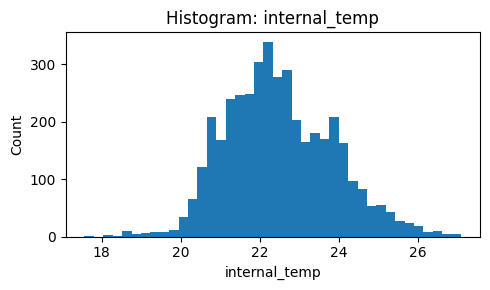

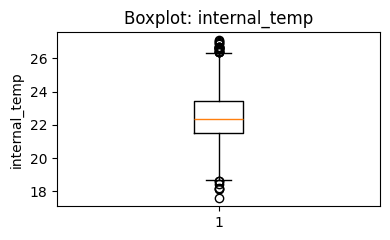

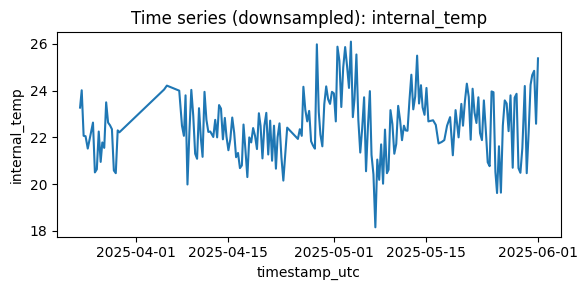

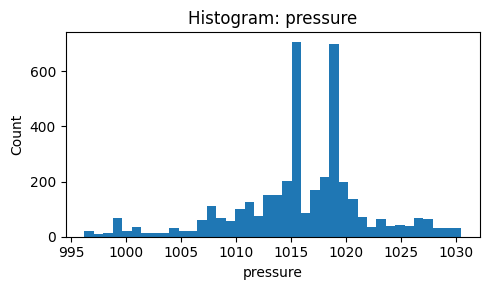

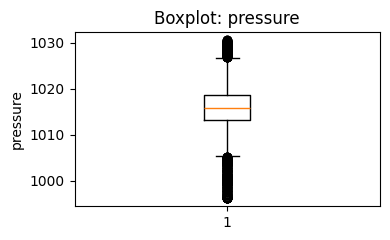

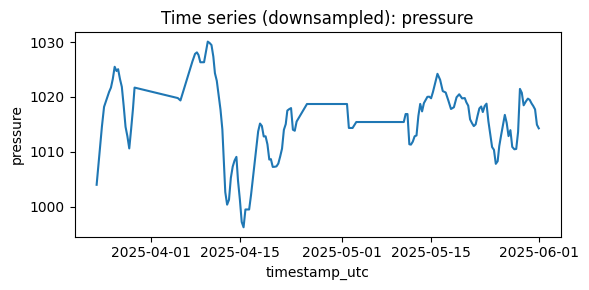

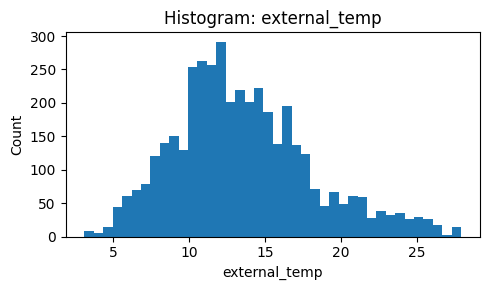

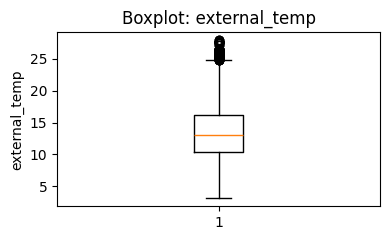

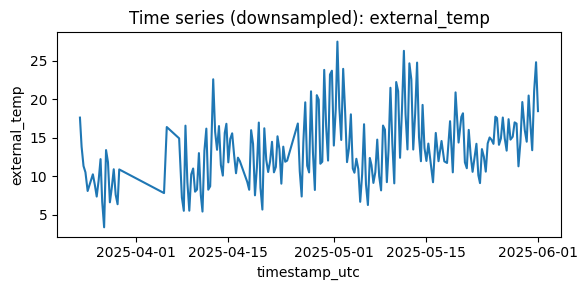

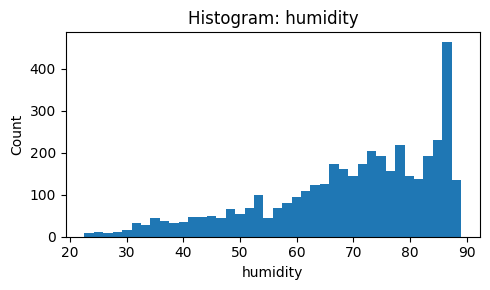

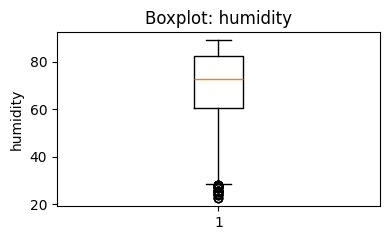

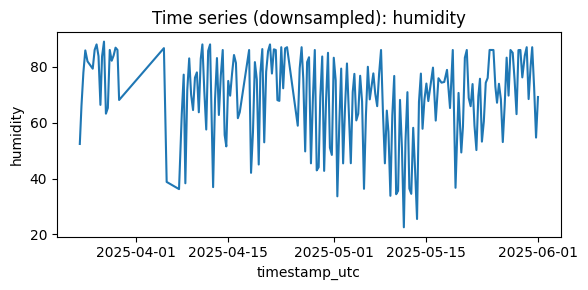

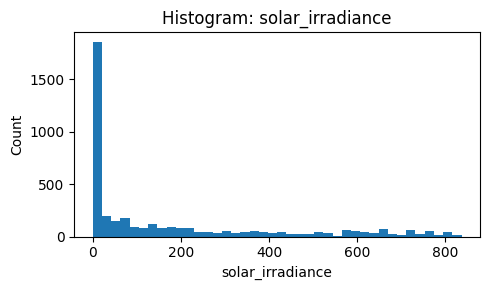

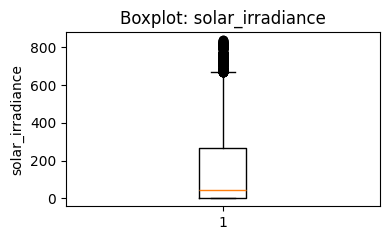

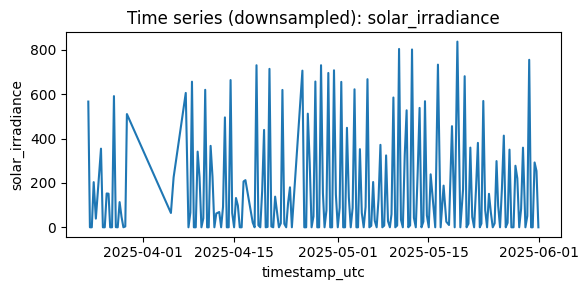

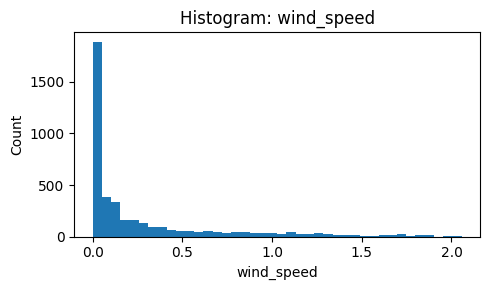

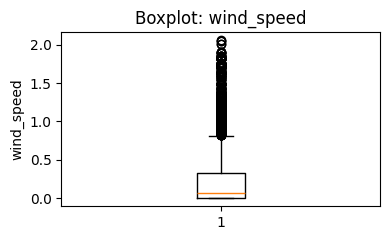

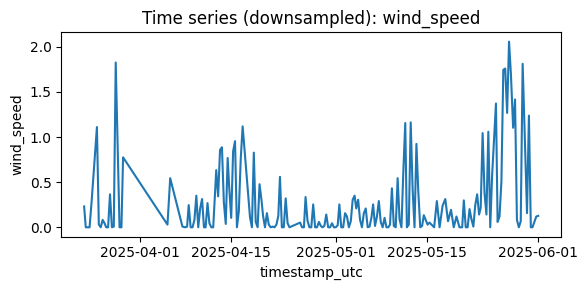

In [24]:
# === Univariate checks for each numeric feature in cleaned_for_xgb ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dfu = cleaned_for_xgb.copy()
dfu["timestamp_utc"] = pd.to_datetime(dfu["timestamp_utc"], utc=True, errors="coerce")

# Grab ONLY numeric columns via pandas (avoids datetime dtype issues)
num_cols = dfu.select_dtypes(include=["number"]).columns.tolist()

# If you want to exclude the target from the generic loop, remove it here (optional)
# num_cols = [c for c in num_cols if c != "internal_temp"]

# Move 'internal_temp' to the front if present (so you see it first)
if "internal_temp" in num_cols:
    num_cols = ["internal_temp"] + [c for c in num_cols if c != "internal_temp"]

print("Numeric columns considered:", num_cols)

for col in num_cols:
    series = dfu[["timestamp_utc", col]].dropna().sort_values("timestamp_utc")

    # Histogram
    plt.figure(figsize=(5,3))
    plt.hist(series[col].values, bins=40)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col); plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # Boxplot
    plt.figure(figsize=(4,2.5))
    plt.boxplot(series[col].values, vert=True, showfliers=True)
    plt.title(f"Boxplot: {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

    # Time series (downsample to avoid overplotting)
    if len(series) > 200:
        idx = np.linspace(0, len(series)-1, 200).astype(int)
        series_plot = series.iloc[idx]
    else:
        series_plot = series

    plt.figure(figsize=(6,3))
    plt.plot(series_plot["timestamp_utc"], series_plot[col])
    plt.title(f"Time series (downsampled): {col}")
    plt.xlabel("timestamp_utc"); plt.ylabel(col)
    plt.tight_layout()
    plt.show()

#### 2b. Correlation check (statistical association) between features and target (int temp)
simple pairwise correlations (e.g., Pearson’s r) between each feature and the target (internal temperature). This tells us about the strength and direction of linear association (e.g., “when external temp rises, does internal temp also rise?”). Only picks up linear relationships (e.g., a U-shaped effect will show weak correlation) (unlice feature imporatance plots - covered later). Doesn’t consider feature interactions (such as external temp + solar together). Doesn’t say how a model will actually use that feature.

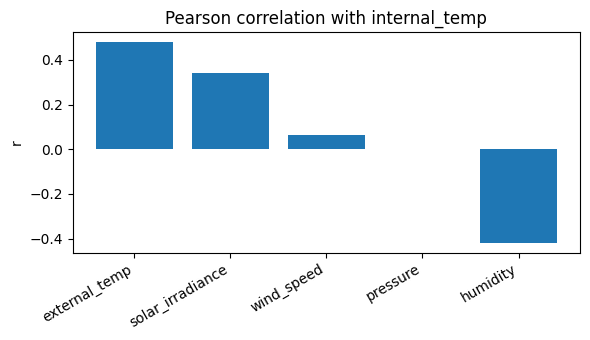

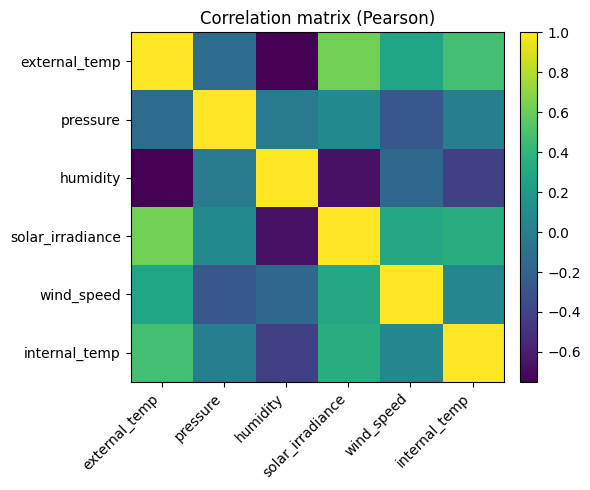

In [32]:
# === Correlation checks ===
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

dfc = cleaned_for_xgb.copy()

# Choose candidate features present in the data
candidate = ["external_temp", "pressure", "humidity", "solar_irradiance", "wind_speed", "room_volume", "internal_temp"]
cols = [c for c in candidate if c in dfc.columns]

corr = dfc[cols].corr(method="pearson")

# 2a) Correlation with target (internal_temp)
if "internal_temp" in corr.columns:
    tgt_corr = corr["internal_temp"].drop(labels=["internal_temp"], errors="ignore").sort_values(ascending=False)

    plt.figure(figsize=(6,3.5))
    plt.bar(tgt_corr.index, tgt_corr.values)
    plt.title("Pearson correlation with internal_temp")
    plt.ylabel("r")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# 2b) Full correlation matrix heatmap
plt.figure(figsize=(6,5))
im = plt.imshow(corr.values, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation matrix (Pearson)")
plt.tight_layout()
plt.show()

#### 2c. Feature importance plots (model-derived)
After training XGBoost - inspect how often and how strongly each feature contributed to decision splits in the trees. Types of importance in XGB:
* Gain: Improvement in accuracy from a feature’s splits.
* Weight: How many times it was used in splits.
* Cover: How many observations were affected by splits on that feature.

Can capture nonlinear effects & interactions (since tree models handle that). Informs about - how much the trained model actually relied on each feature.
Note - FI is model dependent - so importances may shift if train/test split changes

RMSE: 1.6725954340931193
MAE : 1.451243535696077
R^2 : -0.4167378252874758


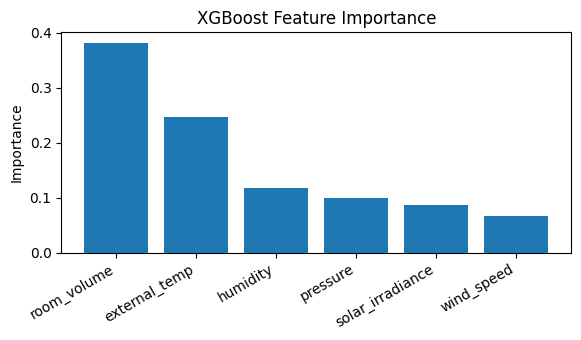

In [33]:
# === XGBoost feature importance (pooled) ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

dff = cleaned_for_xgb.copy()
dff["timestamp_utc"] = pd.to_datetime(dff["timestamp_utc"], utc=True, errors="coerce")

# If room_volume is not yet in dff, map it here (optional)
if "room_volume" not in dff.columns:
    room_volume_map = {
        "BG.West.010": 440,
        "BG.West.270": 202,
        "01.West.120": 122,
    }
    if "sensor" in dff.columns:
        dff["room_volume"] = dff["sensor"].map(room_volume_map)

# Pick features that exist in your frame
candidate_feats = ["external_temp", "pressure", "humidity", "solar_irradiance", "wind_speed", "room_volume"]
feature_cols = [c for c in candidate_feats if c in dff.columns]
target_col = "internal_temp"

# Global 80/20 time split to avoid leakage
g = dff.dropna(subset=feature_cols + [target_col, "timestamp_utc"]).sort_values("timestamp_utc").reset_index(drop=True)
split_idx = int(0.8 * len(g))
X_train, y_train = g.loc[:split_idx-1, feature_cols], g.loc[:split_idx-1, target_col]
X_test,  y_test  = g.loc[split_idx:, feature_cols],  g.loc[split_idx:,  target_col]

model = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)
model.fit(X_train, y_train)

# Evaluate quickly (optional)
y_pred = model.predict(X_test)
print("RMSE:", float(np.sqrt(mean_squared_error(y_test, y_pred))))
print("MAE :", float(mean_absolute_error(y_test, y_pred)))
print("R^2 :", float(r2_score(y_test, y_pred)))

# Plot feature importances
importances = getattr(model, "feature_importances_", None)
if importances is None:
    print("No importances found on this model.")
else:
    order = np.argsort(importances)[::-1]
    sorted_feats = [feature_cols[i] for i in order]
    sorted_imps  = importances[order]

    plt.figure(figsize=(6,3.5))
    plt.bar(sorted_feats, sorted_imps)
    plt.title("XGBoost Feature Importance")
    plt.ylabel("Importance")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

### 3. XGB performance with additional training data

In [34]:
# === XGBoost evaluation with increasing training data (pooled across all sensors) ===
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ensure timestamp is datetime
df_model = cleaned_for_xgb.copy()
df_model["timestamp_utc"] = pd.to_datetime(df_model["timestamp_utc"], utc=True)

# Room volume mapping (if you want it in all runs)
room_volume_map = {
    "BG.West.010": 440,
    "BG.West.270": 202,
    "01.West.120": 122,
}
df_model["room_volume"] = df_model["sensor"].map(room_volume_map)

# Choose full feature set for this test
feature_cols = ["room_volume", "external_temp", "pressure", "humidity", "solar_irradiance", "wind_speed"]

# Define training cutoffs
training_scenarios = [
    ("Jan_Feb",   pd.Timestamp("2025-02-28 23:59:59", tz="UTC")),
    ("Jan_Mar",   pd.Timestamp("2025-03-31 23:59:59", tz="UTC")),
    ("Jan_Apr",   pd.Timestamp("2025-04-30 23:59:59", tz="UTC")),
]

results = []

for scenario_name, train_end in training_scenarios:
    # Split by time (pooled across all sensors)
    train_df = df_model[df_model["timestamp_utc"] <= train_end]
    test_df  = df_model[df_model["timestamp_utc"] > train_end]

    # Drop NaNs in features or target
    cols_needed = feature_cols + ["internal_temp"]
    train_df = train_df.dropna(subset=cols_needed)
    test_df  = test_df.dropna(subset=cols_needed)

    if train_df.empty or test_df.empty:
        print(f"[WARN] {scenario_name}: Not enough data for train/test split.")
        continue

    X_train = train_df[feature_cols]
    y_train = train_df["internal_temp"]
    X_test  = test_df[feature_cols]
    y_test  = test_df["internal_temp"]

    # Train model
    model = XGBRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )
    model.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = model.predict(X_test)
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae  = float(mean_absolute_error(y_test, y_pred))
    r2   = float(r2_score(y_test, y_pred))

    results.append({
        "scenario": scenario_name,
        "train_end": train_end,
        "n_train": len(train_df),
        "n_test": len(test_df),
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
    })

# Show results
results_df = pd.DataFrame(results).sort_values("scenario").reset_index(drop=True)
print("\nXGBoost performance with increasing training data:")
print(results_df)

[WARN] Jan_Feb: Not enough data for train/test split.

XGBoost performance with increasing training data:
  scenario                 train_end  n_train  n_test      RMSE       MAE  \
0  Jan_Apr 2025-04-30 23:59:59+00:00     2025    2089  1.404683  1.123963   
1  Jan_Mar 2025-03-31 23:59:59+00:00      396    3718  1.332270  1.052836   

         R2  
0  0.125923  
1  0.065091  


NOTES - 
1. When I first ran the code with different time brackets () the data wasn't suffienct
2. upon changing the date ranges, the issue arised that Jan-April had worse score than Jan-Mar - this was probably because the test set for Jan-April had only May data while Jan-Mar had A+May data. Output then:
            [WARN] Jan_Feb: Not enough data for train/test split.

            XGBoost performance with increasing training data:
            scenario                 train_end  n_train  n_test      RMSE       MAE  \
            0  Jan_Apr 2025-04-30 23:59:59+00:00     2025    2089  1.404683  1.123963   
            1  Jan_Mar 2025-03-31 23:59:59+00:00      396    3718  1.332270  1.052836   

                    R2  
            0  0.125923  
            1  0.065091  
 To resolve this, I then ran the test with test data as May only for both cases for a fair comparison